In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------


# When should you suspect a second liquid phase? (Figures 11.3-1 and 11.3-2)

This notebook draws **Figures 11.3-1 and 11.3-2** — the complete phase diagram of
isobutane + furfural at 37.8 °C, and the pressure curve that gives the game away.

**Both were computed, not measured.** The 5e made them with the legacy programs the
chapter used to send readers to, and they are the two figures in Section 11.3 that a
reader could never check: nothing about them is experimental, so the only way to know
they are right is to recompute them. Everything here comes from the van Laar constants
Illustration 11.2-2 prints, $\alpha = 2.62$ and $\beta = 3.02$, and the two vapor
pressures at 37.8 °C — nothing is fitted and nothing is read off the old art.

**Figure 11.3-2 is the one with the lesson in it.** Compute the bubble pressure of this
mixture the ordinary Section 10.2 way, ignoring the possibility of two liquid phases,
and you get a curve with a maximum *and* a minimum. Read literally that says the mixture
has a **double azeotrope** — both a minimum-boiling and a maximum-boiling one. Double
azeotropes are real but very rare, and they happen between species of similar volatility;
isobutane and furfural differ by a factor of a thousand in vapor pressure. So the curve
is not telling you about azeotropes. It is telling you that the single-liquid assumption
has failed, and that a liquid-liquid calculation is the one you should have done.

That is a diagnostic worth having: **a maximum and a minimum in a computed $P$–$x$ curve
is how liquid-liquid equilibrium announces itself inside a vapor-liquid calculation.**

SIS = Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst / August 2026

In [2]:
import sys; sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants

from thermo.activity_models import VanLaar
from thermo.vle import GammaPhi, TabulatedPsat
from thermo.charts import use_book_style
from thermo import lle

use_book_style()
BAR = constants.bar
T = 273.15 + 37.8                      # 37.8 C, the temperature of both figures

# Illustration 11.2-2's van Laar constants for isobutane (1) + furfural (2),
# from SIS Table 9.5-1, and the two vapor pressures the text of Sec. 11.3 quotes.
vl = VanLaar(2.62, 3.02)
PSAT = (4.956, 0.005)                  # bar, isobutane and furfural at 37.8 C
gp = GammaPhi([TabulatedPsat(PSAT[0] * BAR, T), TabulatedPsat(PSAT[1] * BAR, T)],
              vl, names=["isobutane", "furfural"])

print(f"  isobutane Psat {PSAT[0]:.3f} bar,  furfural Psat {PSAT[1]:.3f} bar"
      f"   ratio {PSAT[0] / PSAT[1]:.0f} : 1")

  isobutane Psat 4.956 bar,  furfural Psat 0.005 bar   ratio 991 : 1


## The three-phase state, and the numbers the illustration prints

Illustration 11.3-1 works this out by hand: take the liquid-liquid compositions from
Illustration 11.2-2, assume they do not move with pressure (liquids are nearly
incompressible), and bubble-point either phase. Both give the same pressure, as they
must. `vlle_binary` does the whole thing at once.

In [3]:
P3, y3, xI, xII = lle.vlle_binary(gp, T)
P3_bar, aI, aII = P3 / BAR, xI[0], xII[0]

for label, got, want in [("three-phase pressure, bar", P3_bar, 4.69),
                         ("liquid I,  x isobutane",    aI,     0.1128),
                         ("liquid II, x isobutane",    aII,    0.9284),
                         ("vapor,     y isobutane",    y3[0],  0.999)]:
    print(f"  {label:28s} {got:9.4f}   book {want}")

print(f"\n  the two liquids bubble at the same pressure, as the phase rule requires:")
for name, x in (("liquid I ", xI), ("liquid II", xII)):
    Pb, yb = gp.bubble_pressure(x, T)
    print(f"    {name}  P = {Pb / BAR:.4f} bar,  y_isobutane = {yb[0]:.4f}")

  three-phase pressure, bar       4.6869   book 4.69
  liquid I,  x isobutane          0.1128   book 0.1128
  liquid II, x isobutane          0.9284   book 0.9284
  vapor,     y isobutane          0.9990   book 0.999

  the two liquids bubble at the same pressure, as the phase rule requires:
    liquid I   P = 4.6869 bar,  y_isobutane = 0.9990
    liquid II  P = 4.6869 bar,  y_isobutane = 0.9990


### An erratum: the text and the illustration disagree by three in the last digit

The paragraph that describes Figure 11.3-1 says two liquid phases exist for

> 0.1125 &lt; $x_1$ &lt; 0.9284

but Illustration 11.3-1's own results table gives the isobutane mole fraction in liquid I
as **0.1128**, and the calculation above returns 0.1128. The upper bound, 0.9284, agrees
in both places. So the lower bound is a typo in the prose, not a different calculation —
recorded as **E9** in `revision_notes/c11.md`.

It is a small thing, and it is exactly the kind of thing that only turns up when the
figure is redrawn: nobody reading the sentence would notice, because the number is
right in the table on the facing page.

## Figure 11.3-1 — the complete phase diagram

Six regions, and the shape of the diagram is set by the enormous volatility difference:
isobutane's vapor pressure at 37.8 °C is about a thousand times furfural's.

| region | what is there |
|---|---|
| $L_1$, $L_2$ | one liquid — isobutane-rich, furfural-rich |
| LLE | two liquids, above the three-phase pressure |
| VLLE | the horizontal line: two liquids **and** a vapor, at one pressure only |
| VLE | a liquid and a vapor |
| V | vapor alone |

Two features the text points out and the recomputation reproduces. The vapor is more
than 99.9 % isobutane over almost the whole range, so **the dew curve is
indistinguishable from the right-hand axis**; and the vapor region is squeezed into so
thin a strip along the bottom that it is barely visible at this scale. Both are drawn as
they come out, not adjusted.

Above the three-phase line there is no vapor left, and what closes the LLE region off on
either side is the **liquid-liquid solubility curve** — the boundary between two liquids
and one, at $x_1 = 0.1128$ and $x_1 = 0.9284$. It is drawn vertical because Illustration
11.3-1 takes the two liquid compositions to be independent of pressure, which is the same
assumption that gives the three-phase pressure in the first place.

The VLLE line is a *line*, not an area — the phase rule leaves one degree of freedom
for two components in three phases, and temperature has spent it. So it is labeled with
a leader rather than by dropping text into a region, which would imply an area that does
not exist.

  three-phase line drawn at 4.687 bar from x1 = 0.1128 to 0.9284
  LLE closed by verticals at x1 = 0.1128 and 0.9284, up to 6.2 bar
  dew curve reaches y1 = 0.0014 at its lowest


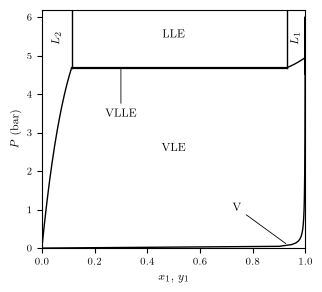

In [4]:
# --- Print art: Figure 11.3-1 ----------------------------------------------
#   pdf/Figure_11.3-1.pdf -> deliverables/figures/print-bw/ch11/c11f015.pdf
#
# Pure black ink; regions separated by line weight and position, never by tint.
# The three-phase line is the heaviest stroke on the figure because it is the one
# locus the whole diagram is organized around.

def bubble(x1):
    P, y = gp.bubble_pressure(np.array([x1, 1.0 - x1]), T)
    return P / BAR, y[0]


xl = np.linspace(1e-7, aI, 500)
xr = np.linspace(aII, 1 - 1e-7, 500)
xa = np.linspace(1e-7, 1 - 1e-7, 1500)
Pl = np.array([bubble(v)[0] for v in xl])
Pr = np.array([bubble(v)[0] for v in xr])
Pa, ya = np.array([bubble(v) for v in xa]).T

PTOP = 6.2                                              # top of the axes

fig, ax = plt.subplots(figsize=(3.4, 3.1))
ax.plot(xl, Pl, "-", color="k", lw=1.0)                 # bubble curve, furfural side
ax.plot(xr, Pr, "-", color="k", lw=1.0)                 # bubble curve, isobutane side
ax.plot(ya, Pa, "-", color="k", lw=1.0)                 # dew curve
ax.plot([aI, aII], [P3_bar, P3_bar], "-", color="k", lw=1.6)   # the three-phase line

# Above the three-phase line there is no vapor left, so the LLE region has to be closed
# off on each side by the liquid-liquid solubility curve -- the boundary between two
# liquids and one. Illustration 11.3-1 takes those compositions to be independent of
# pressure, which is what makes the two boundaries vertical; without them the diagram
# shows an LLE label floating in a region with no edges.
ax.plot([aI, aI], [P3_bar, PTOP], "-", color="k", lw=1.0)      # $L_2$ | LLE
ax.plot([aII, aII], [P3_bar, PTOP], "-", color="k", lw=1.0)    # LLE | $L_1$

ax.set_xlim(0, 1)
ax.set_ylim(0, PTOP)
ax.set_xlabel(r"$x_1$, $y_1$", fontsize=8)
ax.set_ylabel(r"$P$ (bar)", fontsize=8)
ax.set_xticks(np.arange(0, 1.01, 0.2))
ax.tick_params(labelsize=7)

for (x, y), s in [((0.50, 5.55), "LLE"), ((0.50, 2.60), "VLE")]:
    ax.text(x, y, s, fontsize=8, ha="center", va="center")

# $L_2$ and $L_1$ are strips about a tenth of the axis wide, so their labels are set
# vertically inside the strip rather than horizontally across the boundary line.
for x, s in ((0.055, "$L_2$"), (0.962, "$L_1$")):
    ax.text(x, 5.45, s, fontsize=8, ha="center", va="center", rotation=90)

# VLLE is a line and V is a sliver: both get leaders rather than free-floating text
ax.annotate("VLLE", xy=(0.30, P3_bar), xytext=(0.30, 3.62), fontsize=8,
            ha="center", va="top",
            arrowprops=dict(arrowstyle="-", color="k", lw=0.6, shrinkA=2, shrinkB=1))
ax.annotate("V", xy=(0.93, 0.10), xytext=(0.74, 0.92), fontsize=8,
            ha="center", va="bottom",
            arrowprops=dict(arrowstyle="-", color="k", lw=0.6, shrinkA=2, shrinkB=1))

print(f"  three-phase line drawn at {P3_bar:.3f} bar from x1 = {aI:.4f} to {aII:.4f}")
print(f"  LLE closed by verticals at x1 = {aI:.4f} and {aII:.4f}, up to {PTOP} bar")
print(f"  dew curve reaches y1 = {ya.min():.4f} at its lowest")

## Figure 11.3-2 — the curve that should make you stop

The solid line is the bubble pressure computed the ordinary way, from the van Laar model
alone, with no liquid-liquid calculation anywhere in it. The dashed line is what is
actually true across the two-liquid region: **the pressure does not vary with overall
composition at all**, because the phase rule fixes it.

The areas above and below the dashed line are *not* equal, and are not supposed to be.
This is a pressure-composition diagram, not the pressure-volume diagram of Fig. 7.3-2, so
the equal-area Maxwell construction of Chapter 7 does not apply here. The book says so
explicitly, and it is worth repeating because the picture invites the comparison.

  maximum 6.012 bar at x1 = 0.2702
  minimum 4.526 bar at x1 = 0.8052
  flat three-phase pressure 4.687 bar


Text(0.62, 3.3, 'two liquid phases')

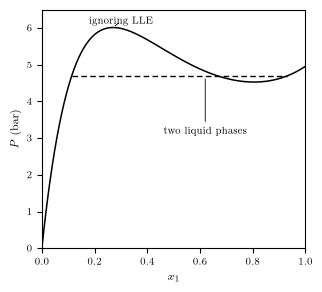

In [5]:
# --- Print art: Figure 11.3-2 ----------------------------------------------
#   pdf/Figure_11.3-2.pdf -> deliverables/figures/print-bw/ch11/c11f016.pdf

i_max = int(np.argmax(Pa))
tail = xa > 0.5
i_min = int(np.argmin(np.where(tail, Pa, np.inf)))
print(f"  maximum {Pa[i_max]:.3f} bar at x1 = {xa[i_max]:.4f}")
print(f"  minimum {Pa[i_min]:.3f} bar at x1 = {xa[i_min]:.4f}")
print(f"  flat three-phase pressure {P3_bar:.3f} bar")

fig2, ax2 = plt.subplots(figsize=(3.4, 3.1))
ax2.plot(xa, Pa, "-", color="k", lw=1.1)
ax2.plot([aI, aII], [P3_bar, P3_bar], "--", color="k", lw=1.0, dashes=(4, 2.4))
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 6.5)
ax2.set_xlabel(r"$x_1$", fontsize=8)
ax2.set_ylabel(r"$P$ (bar)", fontsize=8)
ax2.set_xticks(np.arange(0, 1.01, 0.2))
ax2.tick_params(labelsize=7)
ax2.annotate("ignoring LLE", xy=(xa[i_max], Pa[i_max]), xytext=(0.30, 6.30),
             fontsize=7, ha="center", va="top",
             arrowprops=dict(arrowstyle="-", color="k", lw=0.6, shrinkA=2, shrinkB=2))
ax2.annotate("two liquid phases", xy=(0.62, P3_bar), xytext=(0.62, 3.30),
             fontsize=7, ha="center", va="top",
             arrowprops=dict(arrowstyle="-", color="k", lw=0.6, shrinkA=2, shrinkB=2))

## The two collision tests, then stage both files

Label-against-label is the obvious check and it passes even when a label is sitting on
top of a curve — which is the failure that actually happens. The second test walks every
drawn line in display coordinates and asks whether it enters any label's box. Both
figures have to pass before either is written.

In [6]:
import matplotlib.text as mtext


def renderer(fig):
    """`get_renderer` is on the Agg canvas, not on the bare FigureCanvasBase a
    headless kernel may hand you -- so a gate that passes in JupyterLab can die in a
    batch re-execution, which is exactly where it has to work."""
    try:
        return fig.canvas.get_renderer()
    except AttributeError:
        from matplotlib.backends.backend_agg import FigureCanvasAgg
        canvas = FigureCanvasAgg(fig)
        canvas.draw()
        return canvas.get_renderer()


def collisions(ax):
    fig = ax.figure
    fig.canvas.draw()
    rend = renderer(fig)
    # Measure the TEXT box only. `Annotation.get_window_extent` includes the
    # leader, so an annotation is reported as "sitting on a curve" whenever its
    # leader reaches the curve it points at -- which is the whole job of a leader.
    # Calling Text's own implementation skips the arrow.
    boxes = [(t.get_text(), mtext.Text.get_window_extent(t, renderer=rend))
             for t in ax.texts if (t.get_text() or "").strip()]
    bad = [f"{p} / {q}" for i, (p, bp) in enumerate(boxes)
           for q, bq in boxes[i + 1:] if bp.overlaps(bq)]
    for name, box in boxes:
        pad = box.expanded(1.15, 1.25)
        for line in ax.lines:
            xy = ax.transData.transform(line.get_xydata())
            if any(pad.contains(px, py) for px, py in xy):
                bad.append(f"{name} sits on a curve")
                break
    return sorted(set(bad))


for name, a in (("Figure 11.3-1", ax), ("Figure 11.3-2", ax2)):
    bad = collisions(a)
    print(f"  {name}: {'; '.join(bad) if bad else 'no label collisions'}")
    assert not bad, "move a label before staging this art"

os.makedirs("pdf", exist_ok=True)
for f, path in ((fig, "pdf/Figure_11.3-1.pdf"), (fig2, "pdf/Figure_11.3-2.pdf")):
    f.tight_layout()
    f.savefig(path, dpi=300, bbox_inches="tight")
    print(f"  wrote {path}")

  Figure 11.3-1: no label collisions
  Figure 11.3-2: no label collisions


  wrote pdf/Figure_11.3-1.pdf
  wrote pdf/Figure_11.3-2.pdf


## What the legacy code did, and what replaced it

The 5e produced both of these figures with the programs Section 11.3 named — and the
sentence that named them, *"the Visual Basic program of Appendix B.I-3, the DOS-based
program VLMU, or the MATHCAD worksheet PRBUBP"*, is the one this edition rewrote. That
rewrite is only honest if the figures it points at can be regenerated, which is what this
notebook is for.

Nothing here needs anything outside the package: two vapor pressures, two van Laar
constants, `GammaPhi` for the bubble points and `vlle_binary` for the three-phase state.
The whole calculation is about fifteen lines, which is worth noticing given that it once
took three separate programs in two languages.